# 🧬 K-Means Clustering — Unsupervised Cell Grouping
Self-contained unsupervised workflow: elbow → silhouette → clustering → PCA.


Dataset shape: (569, 30)


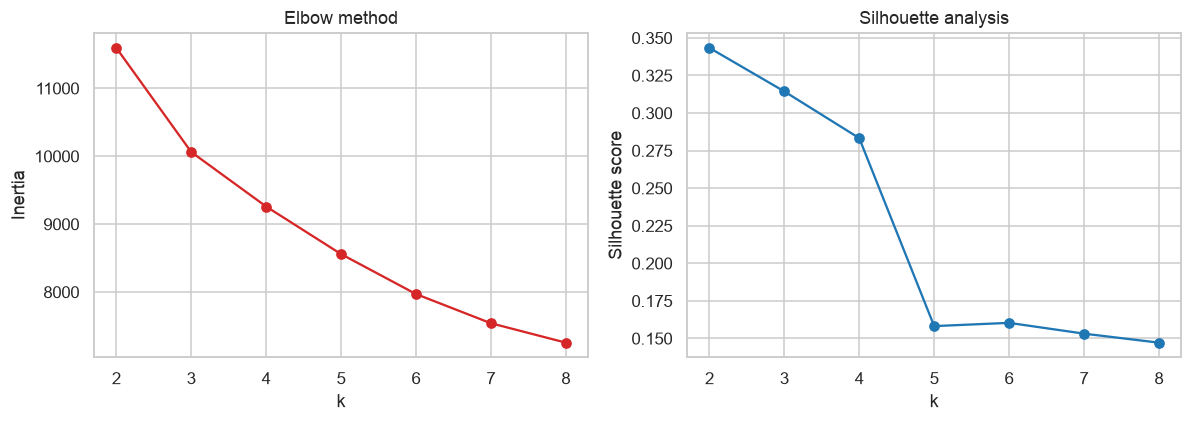

Best k by silhouette score: 2
Adjusted Rand Index (vs true labels): 0.6536
Silhouette score                   : 0.3434
Explained variance (2 PCs): 63.24%


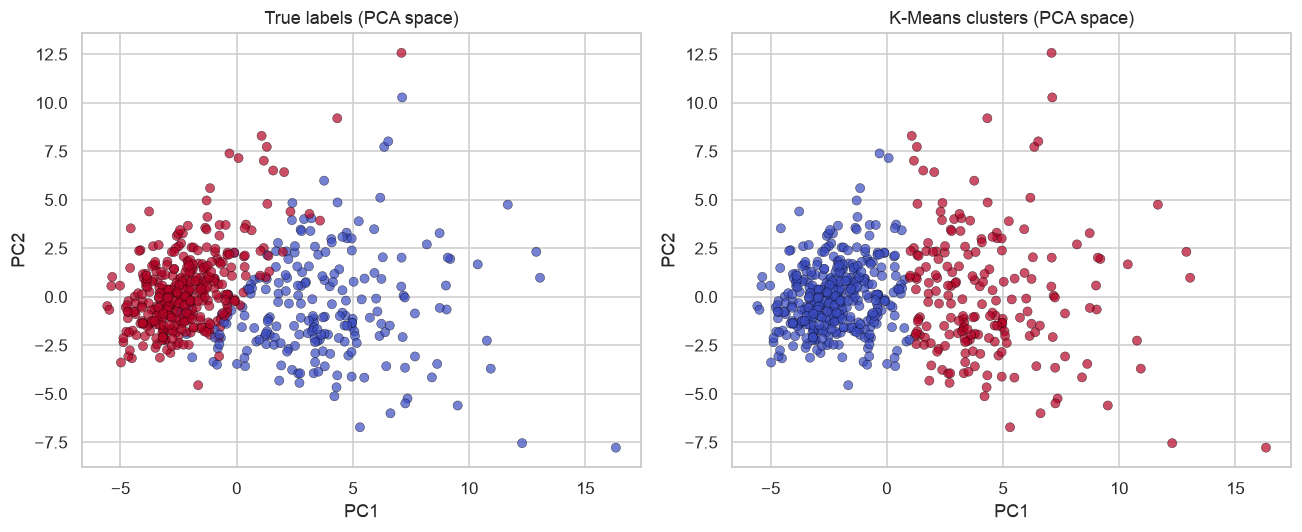

In [1]:
# ============================================================
# Setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

# ============================================================
# Load data + scale (full dataset, unsupervised)
# ============================================================
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f"Dataset shape: {X.shape}")

# ============================================================
# Choose k — elbow method + silhouette score
# ============================================================
inertias, silhouettes, K_range = [], [], range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(K_range, inertias, "o-", color="#d62728")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[1].plot(K_range, silhouettes, "o-", color="#1f77b4")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette analysis")
plt.tight_layout(); plt.show()
best_k = int(K_range[np.argmax(silhouettes)])
print(f"Best k by silhouette score: {best_k}")

# ============================================================
# K-Means clustering (k = 2) + validation vs true labels
# ============================================================
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_sc)
labels_km = km.labels_
ari = adjusted_rand_score(y, labels_km)
sil = silhouette_score(X_sc, labels_km)
print(f"Adjusted Rand Index (vs true labels): {ari:.4f}")
print(f"Silhouette score                   : {sil:.4f}")

# ============================================================
# PCA projection for 2D visualization
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
print(f"Explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm",
                alpha=0.7, edgecolors="k", linewidths=0.3)
axes[0].set_title("True labels (PCA space)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="coolwarm",
                alpha=0.7, edgecolors="k", linewidths=0.3)
axes[1].set_title("K-Means clusters (PCA space)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()
